In [2]:
import jax 
import jax.numpy as jnp
import numpy as np

from jax.typing import ArrayLike
from typing import NamedTuple

import matplotlib.pyplot as plt

import flax.nnx as nnx

from probjax.nn.nets.transformer import  Transformer
from probjax.nn import MLP



from probjax.nn.nets.simple import ResNet

In [3]:
mlp = MLP([1,2,2,1], rngs=nnx.Rngs(jax.random.PRNGKey(0)))

from probjax.nn.nets.simple import ResNet
mlp_def, mlp_params = nnx.split(mlp)

2024-12-03 19:04:18.822438: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.5 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [4]:
params_list, tree = jax.tree_util.tree_flatten(mlp_params)
dims_by_id = {i:int(np.prod(x.shape)) for i,x in enumerate(params_list)}

In [5]:
params_flat, unflatten = jax.flatten_util.ravel_pytree(mlp_params)

In [6]:
NUM_PARAMS = len(params_flat)
NUM_PARAMS

13

In [132]:
def generate_data(rng):
    #x = jax.random.uniform(rng, (10,1), minval=-10, maxval=10)
    rng1, rng2 = jax.random.split(rng)
    x = jnp.linspace(-5,5,10).reshape(-1,1)
    params = jax.random.normal(rng1, (NUM_PARAMS,))
    params_unravel = unflatten(params)
    mlp = nnx.merge(mlp_def, params_unravel)
    y = mlp(x)
    y += jax.random.normal(rng2, y.shape) * 0.1
    data = jnp.concatenate([x, y], axis=-1)
    return params, data.reshape(-1)

@jax.grad
def true_score(params, data):
    x,y = jnp.split(data, 2, axis=-1)
    x = x.reshape(-1,1)
    y = y.reshape(-1,1)
    params_unravel = unflatten(params)
    mlp = nnx.merge(mlp_def, params_unravel)
    y_pred = mlp(x)
    loss = jnp.sum(1/(2*0.1**2)*(y - y_pred)**2)
    return loss

1.2710419


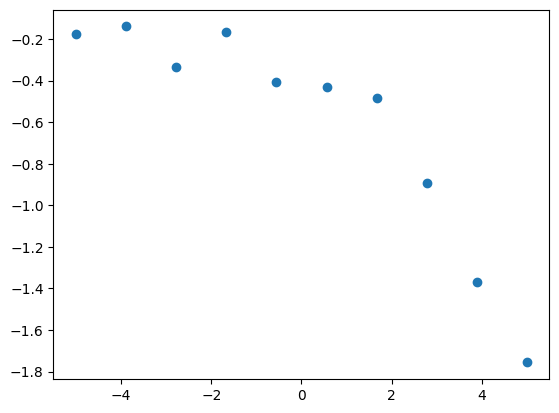

In [135]:
params, data = generate_data(jax.random.PRNGKey(0))
print(params.sum())
plt.plot(data[::2], data[1::2], 'o')

In [140]:
from functools import partial
from probjax.nn import GaussianFourierEmbedding
from probjax.nn.nets.denoising_diffusion_model import EDM, VE, VP
from probjax.nn import DeepSet


class EmbeddingNet(nnx.Module, experimental_pytree=True):
    def __init__(self, d, rngs, hidden_dim=100, num_layers=4) -> None:
        trial_net = MLP([2,50,100,500], rngs=rngs)
        summary_net = MLP([500,200,100], rngs=rngs)
        self.embedding_net = DeepSet(trial_net, summary_net, reduction=jnp.mean)
        
    def __call__(self, data):
        x, y = jnp.split(data, 2, axis=-1)
        xy_pair = jnp.concatenate([x[...,None], y[...,None]], axis=-1)
        return self.embedding_net(xy_pair)


class BaseModel(nnx.Module, experimental_pytree=True):

    hidden_dim=200
    num_layers=5

    def __init__(self, d,d_context, rngs, time_embed_dim=50) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,time_embed_dim, rngs=rngs)
        #self.time_embedding = lambda t: jnp.repeat(t, 5, axis=-1)
        self.resnet = ResNet(d,d,rngs,context_dim=100 + time_embed_dim, num_hidden_layers=self.num_layers, hidden_dim=self.hidden_dim, norm=nnx.LayerNorm)
        
        #self.embedding_net = EmbeddingNet(d_context, rngs)
        self.embedding_net = MLP([d_context, 100, 100], rngs=rngs)

    def __call__(self, t,x, context, *args, **kwargs):
        time_embed = self.time_embedding(t)
        coontext_embed = self.embedding_net(context)
        # Pad context by repeating until it matches the time embedding
        context_emb = jnp.concatenate([coontext_embed, time_embed], axis=-1)

        # Run through resnet
        output = self.resnet(x, context_emb)
        return output + jax.vmap(true_score)(x, context)


In [141]:
thetas, datas = jax.vmap(generate_data)(jax.random.split(jax.random.key(0), 100))
eps = jax.random.normal(jax.random.key(0), shape=thetas.shape)

In [142]:
net = BaseModel(NUM_PARAMS, 20, nnx.Rngs(jax.random.PRNGKey(0)))
model = EDM(net)

graphdef, params, state = nnx.split(model, nnx.Param, nnx.Variable)

In [143]:
node_ids = tuple([0,1,2,3,4,5])

model(jnp.ones((100,1))*0.1, thetas + eps*0.1, context=datas) - thetas

Array([[  -42.435,   300.971,   123.141, ...,   256.328,    -0.198,
         1734.484],
       [    4.601,    -0.707,   -19.577, ...,   -24.636,   -79.536,
           48.246],
       [   91.168,    23.093,  -549.107, ...,   -75.085,  -263.545,
         -279.294],
       ...,
       [  -11.523,    36.065,   -31.554, ...,  -182.079,     3.333,
         -214.058],
       [   -1.909,     2.891,    -2.29 , ...,   -88.735,    15.076,
            5.074],
       [ -103.7  ,   214.211,   245.049, ...,  -360.695, -1526.729,
         -120.034]], dtype=float32)

In [144]:

import optax

scheduler_lr = optax.cosine_onecycle_schedule(1000*20, 5e-4)
opt = optax.chain(optax.adaptive_grad_clip(10.), optax.ema(0.001), optax.adam(scheduler_lr))
opt_state = opt.init(params)
@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(model.loss)(params,rng, x[0], context=x[1])
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [145]:
key = jax.random.PRNGKey(1)

In [146]:
losses = []
for i in range(1000):
    l = 0.
    for j in range(20):
        key,key_data, key_loss = jax.random.split(key, 3)
        xs = jax.vmap(generate_data)(jax.random.split(key_data, 2048))
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    losses.append(l/20)

KeyboardInterrupt: 

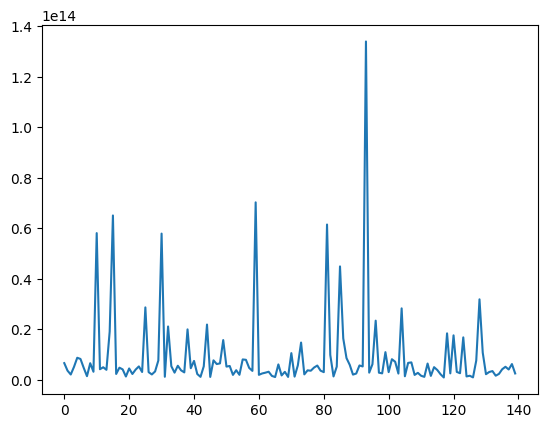

In [147]:
plt.plot(losses)

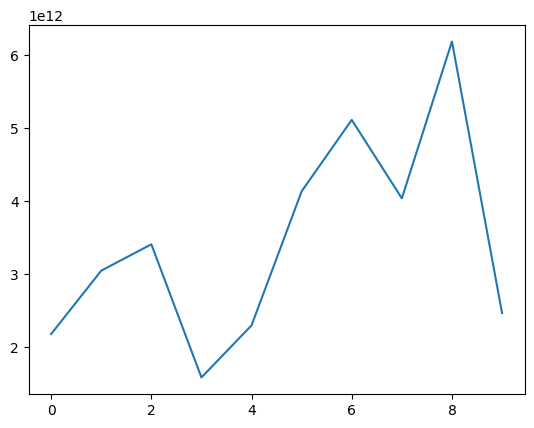

In [148]:
plt.plot(losses[-10:])

In [95]:
model = nnx.merge(graphdef, params, state)

In [96]:
from probjax.utils.odeint import odeint

def sample(rng, context):
    eps = jax.random.normal(rng, (NUM_PARAMS,)) * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(100)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x, context=context)
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts, method="heun")[-1]


In [97]:
theta, x_o = generate_data(jax.random.PRNGKey(0))

In [98]:
samples = jax.vmap(lambda k: sample(k, x_o))(jax.random.split(jax.random.PRNGKey(0), 1000))

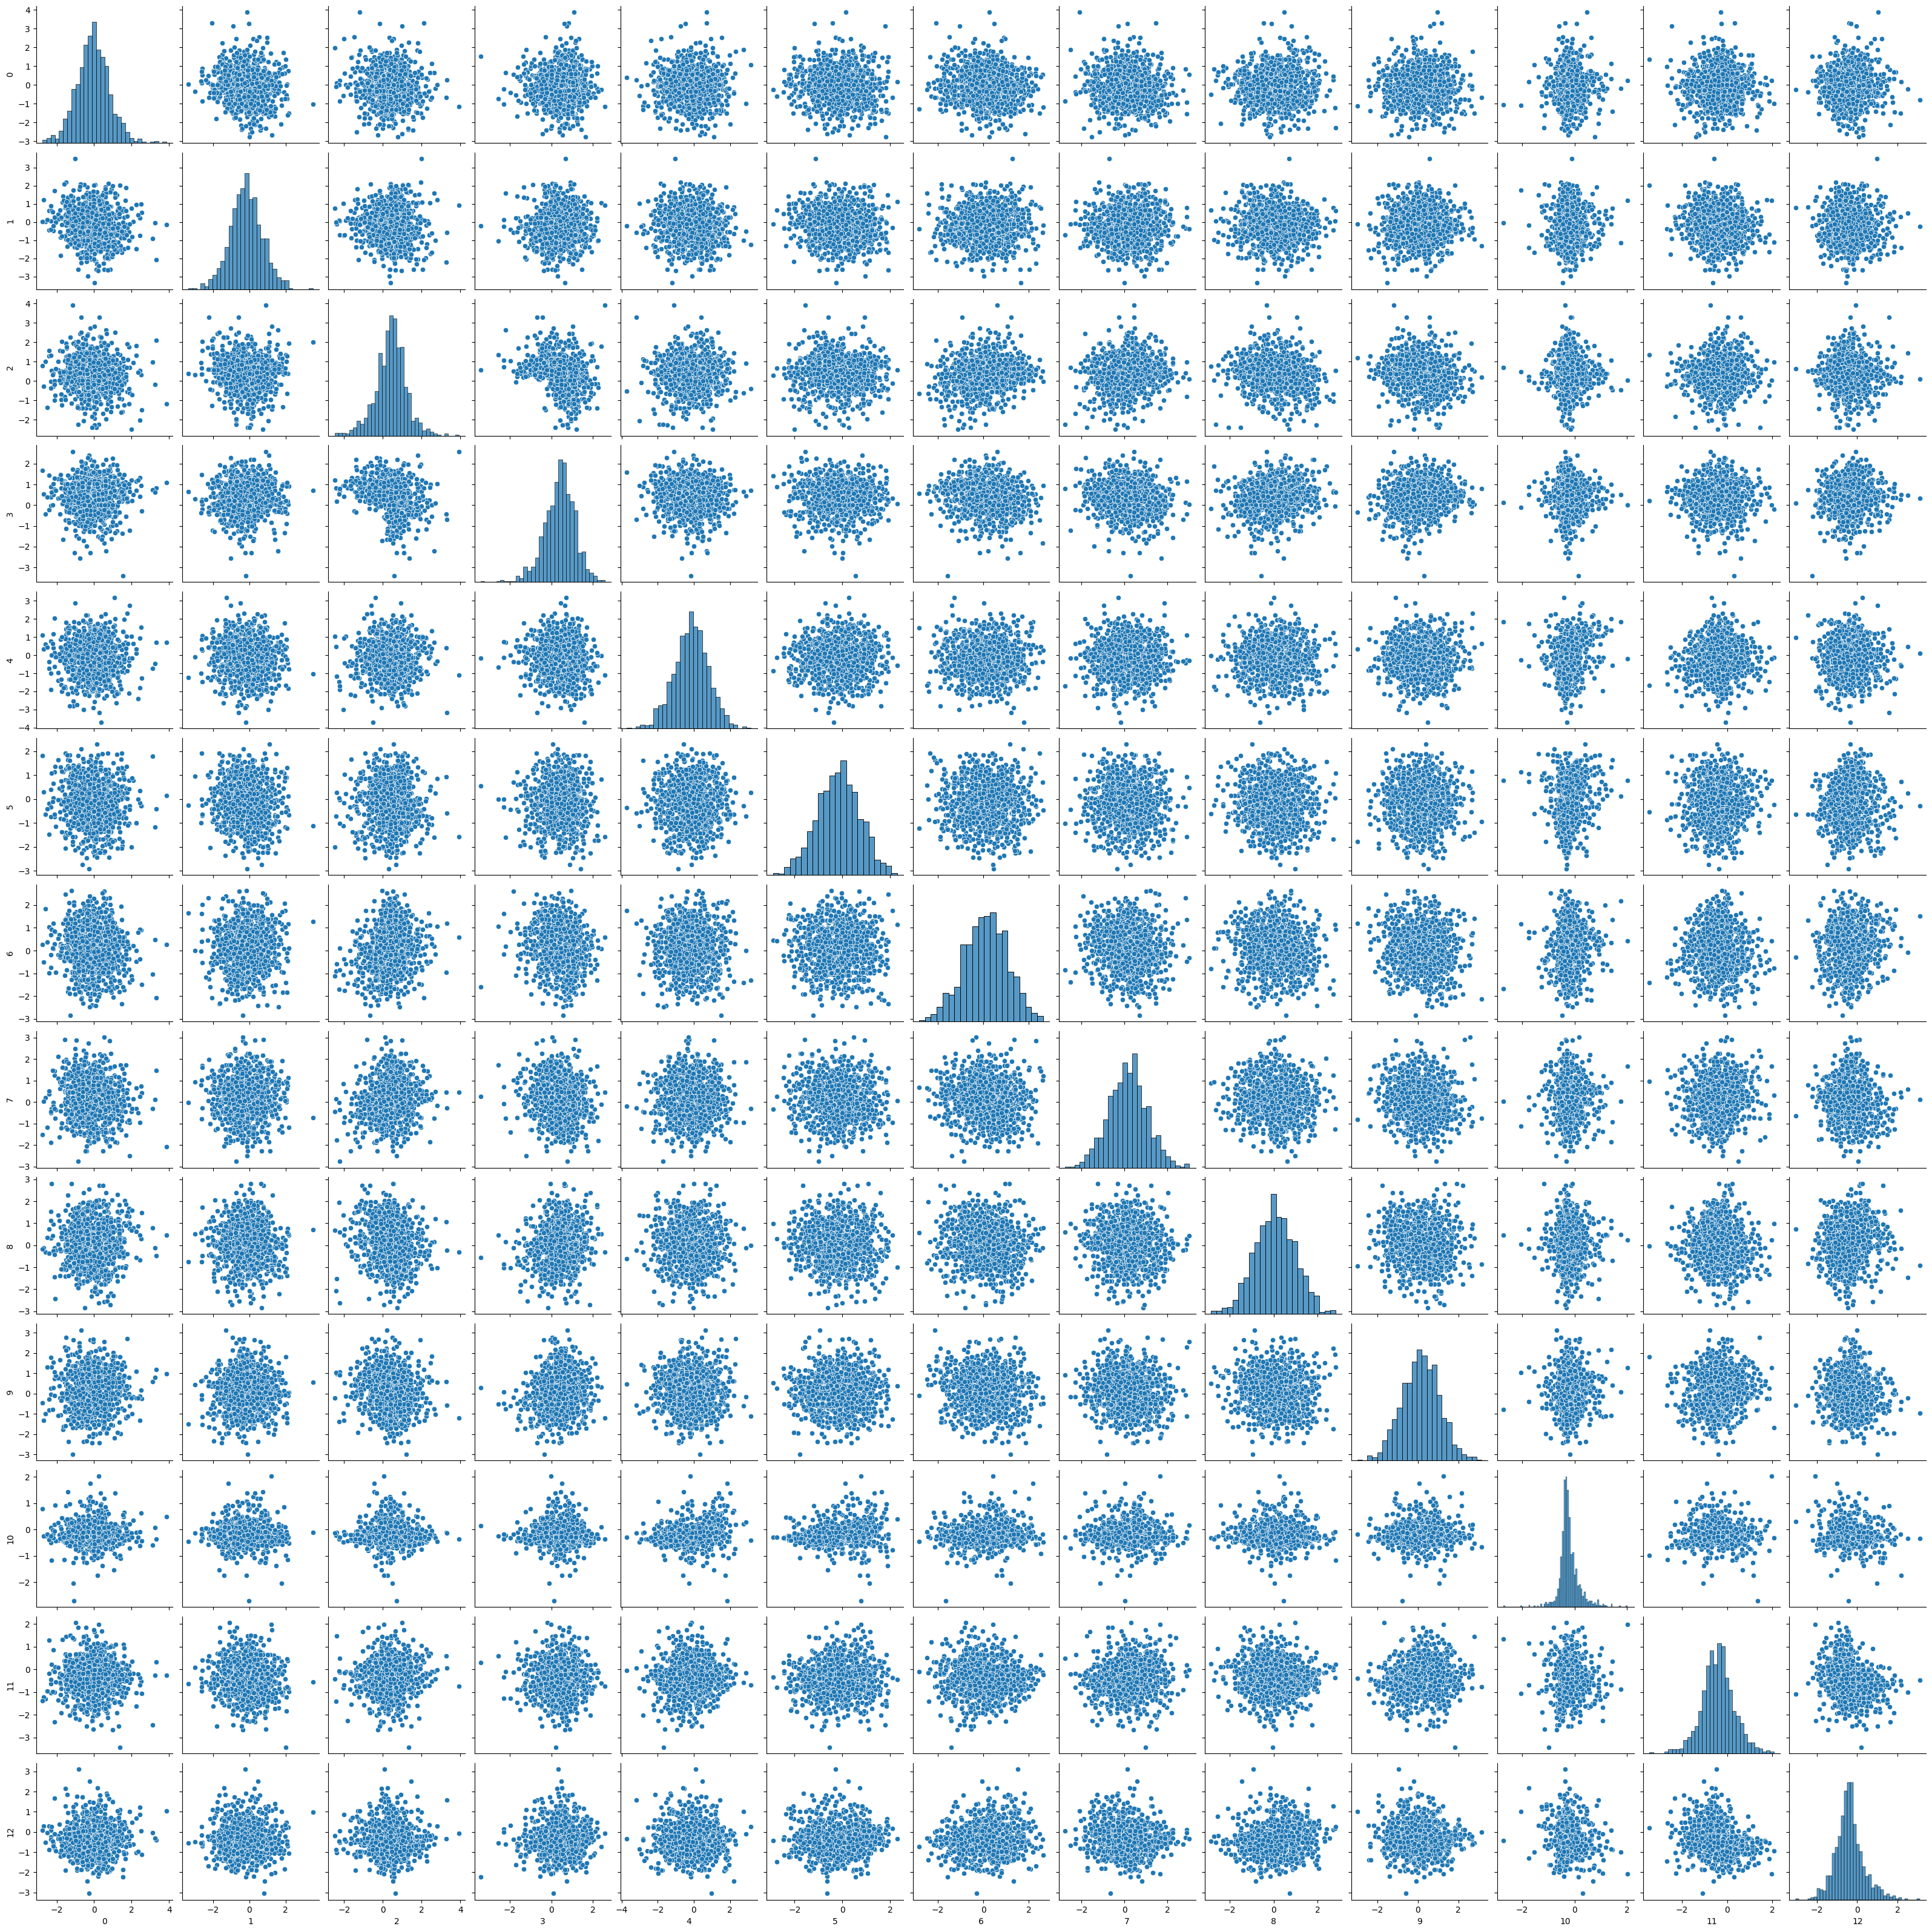

In [86]:
import seaborn as sns
import pandas as pd

sns.pairplot(pd.DataFrame(samples))

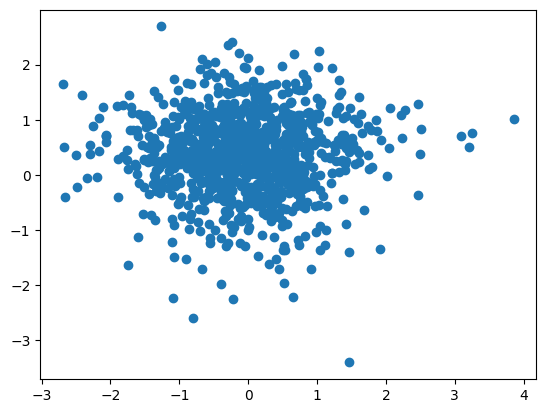

In [99]:
plt.scatter(samples[:,0], samples[:,3])

In [100]:
def pred(params, x):
    unflat_params = unflatten(params)
    mlp = nnx.merge(mlp_def, unflat_params)
    return mlp(x)

In [101]:
ys = jax.vmap(lambda p: pred(p, x_o[::2, None]))(samples)

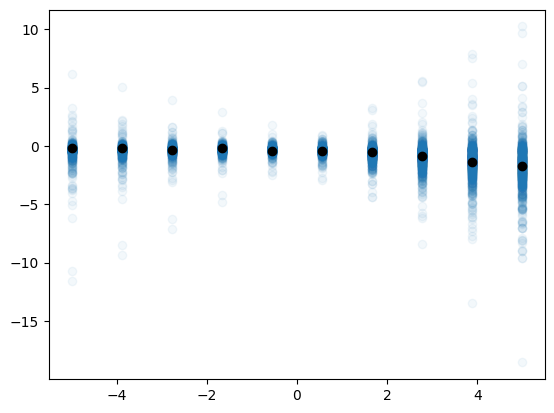

In [102]:
_ = plt.plot(x_o[::2], ys[:,:,0].T, 'o', color="C0", alpha=0.05)
plt.plot(x_o[::2], x_o[1::2], 'o', color="black")